0: LOAD SPLITS
  X_train    : (1479, 69)
  X_val      : (501, 69)
  X_test     : (563, 69)

STEP 1: FEATURE SELECTION — Bypassed (Using all features)
  Original features: 69
  Selected features: 69

STEP 2: CLASS IMBALANCE
  Up=760 Down=719  scale_pos_weight=0.9461

STEP 3: HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit

  [Optuna] LightGBM — 50 trials ...
  ✔ LightGBM best CV AUC : 0.5465

  [Optuna] XGBoost — 50 trials ...
  ✔ XGBoost best CV AUC  : 0.5308

STEP 4: TRAIN BASE MODELS (on Train, Eval on Val)

  --- Ensemble Performance (Default threshold 0.50) ---
  [ENS val] Acc=51.7%  F1=51.7%  Prec=51.6%  Rec=51.6%  AUC=0.5336
  [ENS test] Acc=51.9%  F1=51.6%  Prec=55.7%  Rec=54.8%  AUC=0.5302

STEP 5: THRESHOLD TUNING (Val set)

  Default threshold (0.50) Val Acc: 51.7%
  Optimal threshold (0.51) Val Acc: 52.7%

  --- Test Performance (Tuned thresh=0.51) ---
  [ENS tuned] Acc=50.4%  F1=49.3%  Prec=57.6%  Rec=32.5%  AUC=0.5302

STEP 6: WALK-FORWARD VALIDATION (best_lgb_params)

  

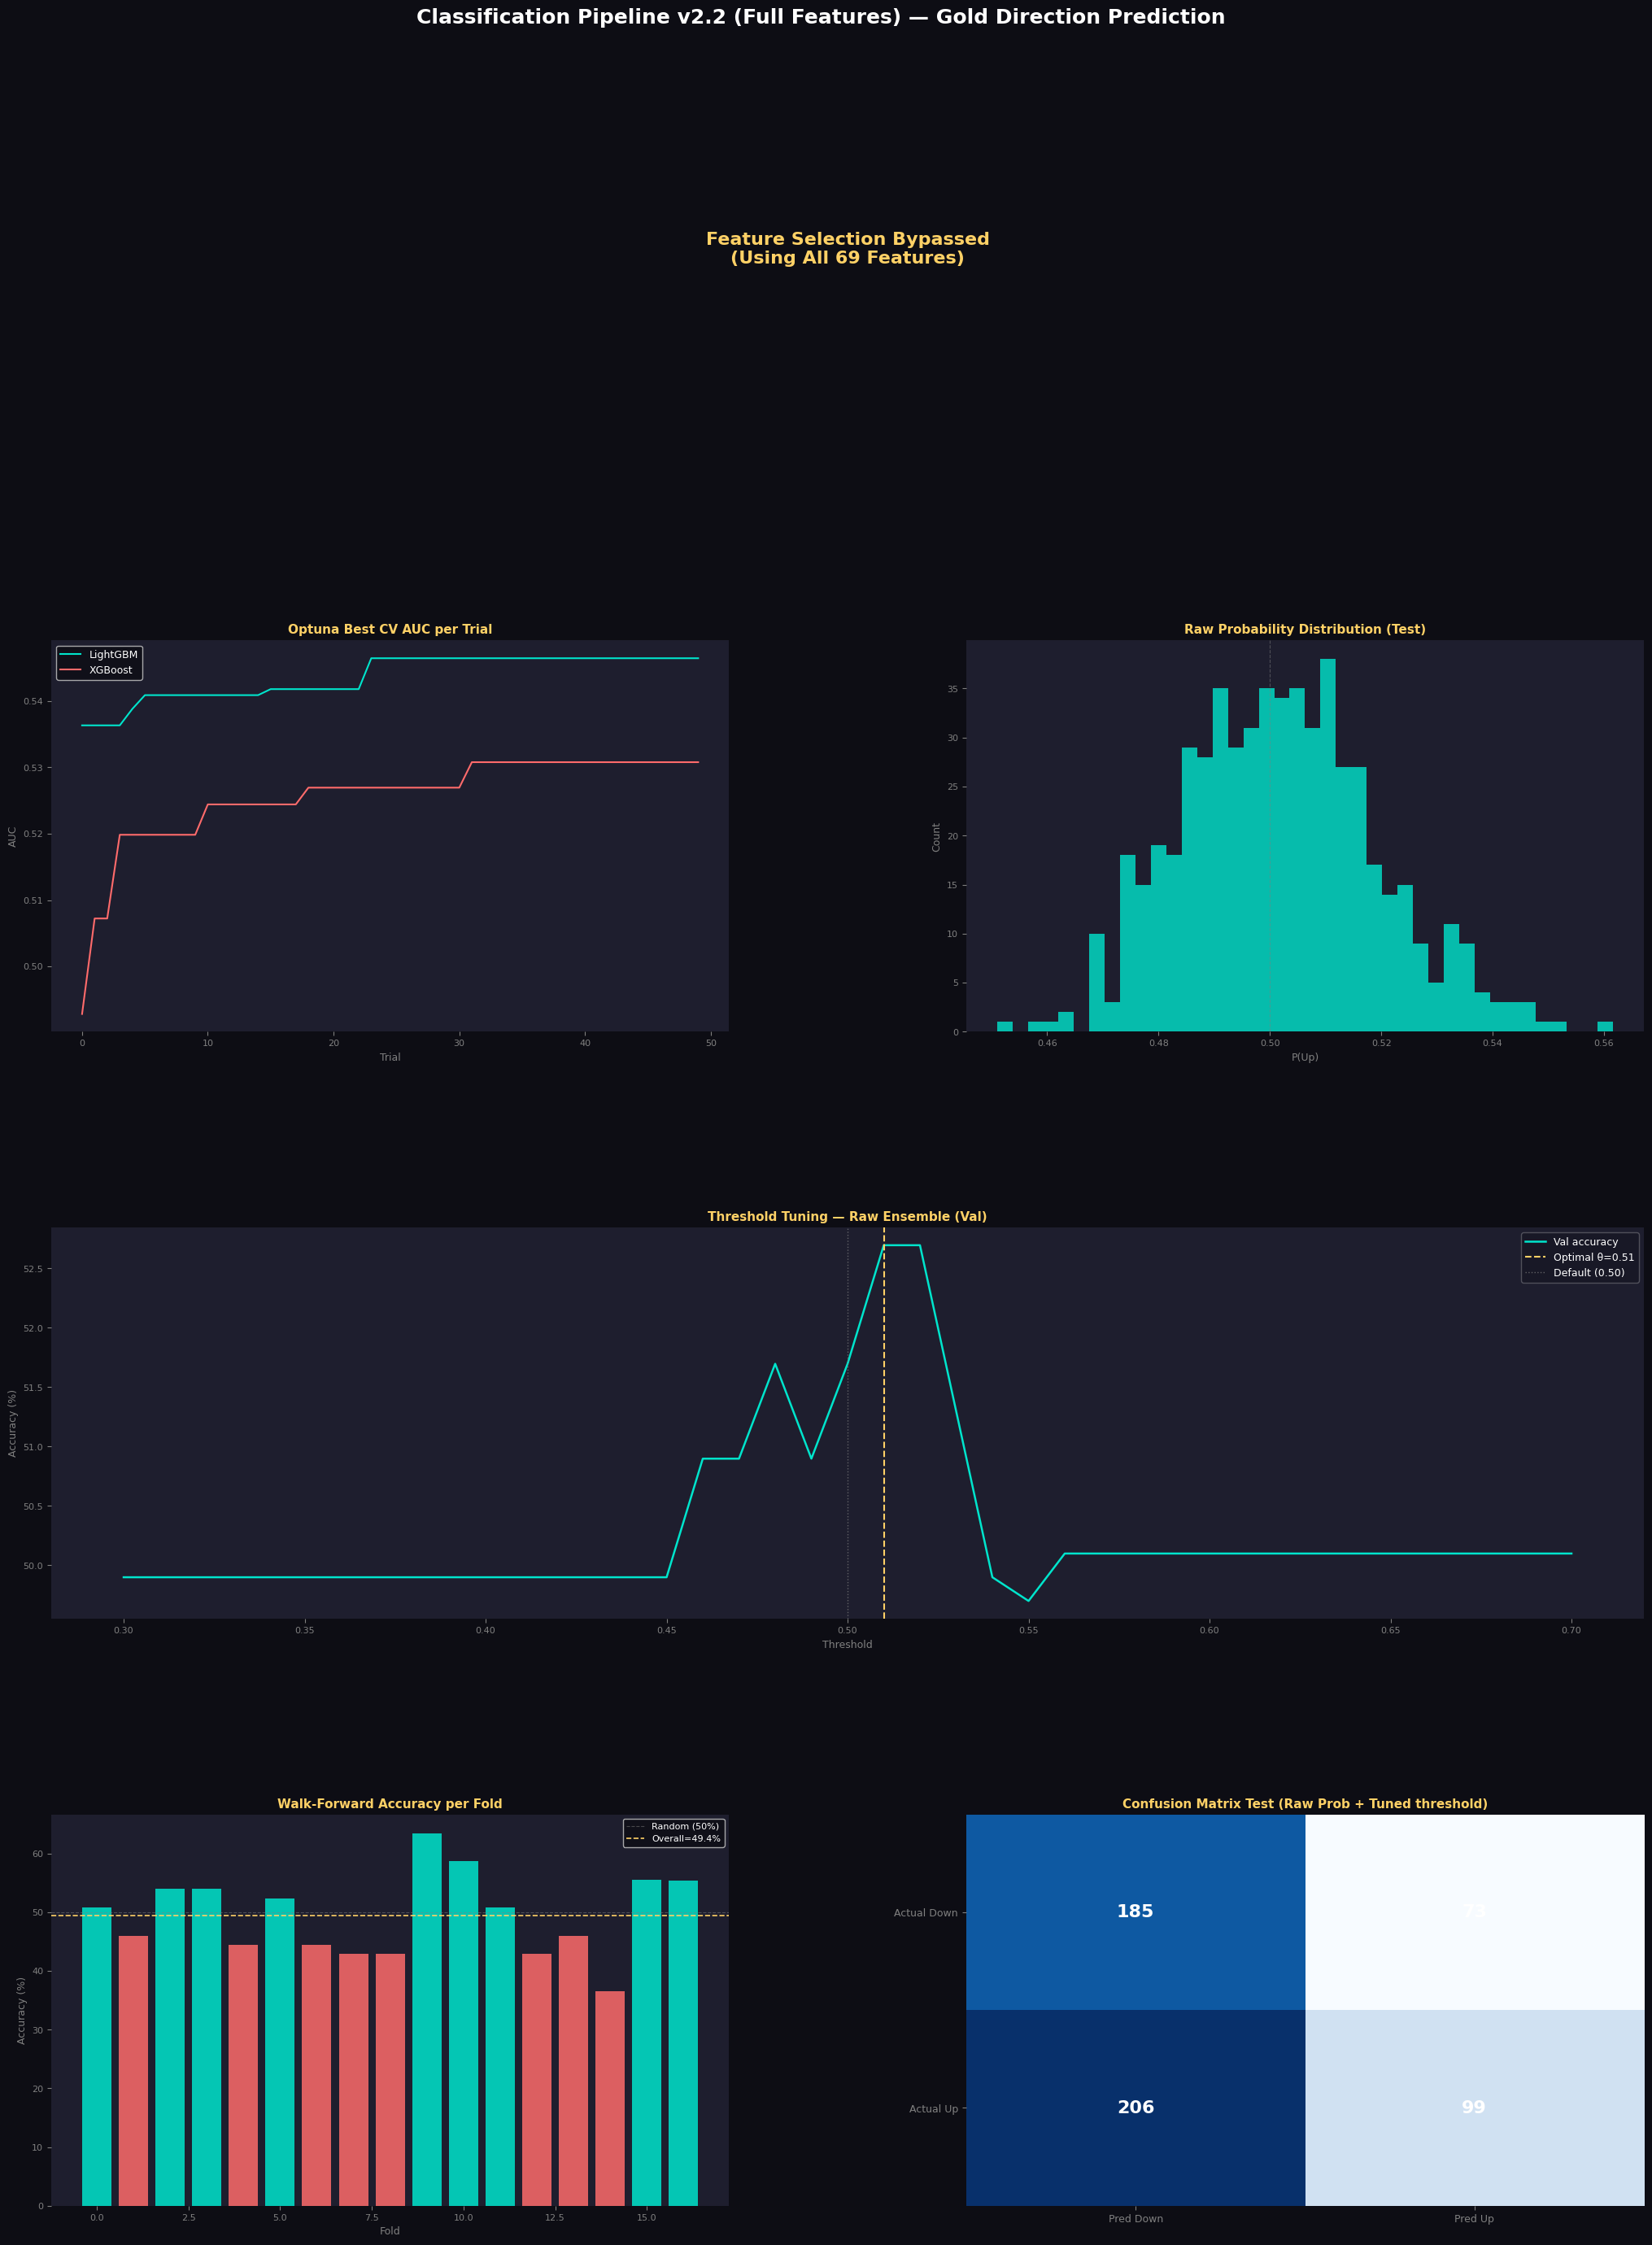


FINAL SUMMARY

  STEP 1 — FEATURE SELECTION
    69 → 69 features (Bypassed, Using All)

  STEP 3 — OPTUNA TUNING
    LightGBM CV AUC : 0.5465
    XGBoost  CV AUC : 0.5308

  STEP 5 — THRESHOLD TUNING (Raw Probabilities)
    Optimal θ       : 0.51
    Test Acc        : 50.4%

  STEP 6 — WALK-FORWARD
    Overall Acc     : 49.4%
    Overall AUC     : 0.4937

  STEP 7 — SIGNAL FUSION (Percentile-Based)
    θ_high / θ_low  : 0.5204 / 0.4803  (Top 15.0% / Bottom 15.0%)
    Test active acc : 53.6%
    Test coverage   : 24.9%

  ✔ Saved → classification_signals_v2_full.csv


In [ ]:
# ============================================================
# CLASSIFICATION PIPELINE v2.2 (FULL FEATURES) — GOLD DIRECTION PREDICTION
# ============================================================
# แก้ไขจาก v2.1:
# - ข้าม STEP 1 (Feature Selection) ทิ้งไป ใช้ Features ครบทั้ง 69 ตัว
# - ตัด Probability Calibration ทิ้ง ป้องกันปัญหา Prob แช่แข็งที่ 0.518
# - ใช้ Raw Probability + Percentile ในการหา Threshold เพื่อให้ระบบกล้าเทรด
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, precision_score, recall_score
)
from sklearn.model_selection import TimeSeriesSplit

# ── reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot style
FIG_COLOR  = "#0D0D14"
ACCENT1    = "#00E5CC"
ACCENT2    = "#FF6B6B"
ACCENT3    = "#FFD166"
ACCENT4    = "#A78BFA"
GRID_COLOR = "#1E1E2E"
plt.style.use("dark_background")

# ============================================================
# 0: LOAD SPLITS
# ============================================================
print("=" * 60)
print("0: LOAD SPLITS")
print("=" * 60)

BASE = "../../../data/processed/splits/"

X_train = pd.read_csv(BASE + "X_train.csv", parse_dates=["Date"], index_col="Date")
X_val   = pd.read_csv(BASE + "X_val.csv",   parse_dates=["Date"], index_col="Date")
X_test  = pd.read_csv(BASE + "X_test.csv",  parse_dates=["Date"], index_col="Date")

y_reg_train = pd.read_csv(BASE + "y_train_reg.csv", parse_dates=["Date"], index_col="Date").squeeze()
y_reg_val   = pd.read_csv(BASE + "y_val_reg.csv",   parse_dates=["Date"], index_col="Date").squeeze()
y_reg_test  = pd.read_csv(BASE + "y_test_reg.csv",  parse_dates=["Date"], index_col="Date").squeeze()

X_trainval     = pd.concat([X_train, X_val])
y_reg_trainval = pd.concat([y_reg_train, y_reg_val])

print(f"  X_train    : {X_train.shape}")
print(f"  X_val      : {X_val.shape}")
print(f"  X_test     : {X_test.shape}")

# Binary labels (Up=1, Down=0)
y_bin_train    = (y_reg_train > 0).astype(int)
y_bin_val      = (y_reg_val > 0).astype(int)
y_bin_test     = (y_reg_test > 0).astype(int)
y_bin_trainval = (y_reg_trainval > 0).astype(int)

# ── HELPER METRICS
def evaluate_clf(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred) * 100
    f1   = f1_score(y_true, y_pred, average="macro") * 100
    prec = precision_score(y_true, y_pred, zero_division=0) * 100
    rec  = recall_score(y_true, y_pred, zero_division=0) * 100
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else float("nan")
    print(f"  [{name}] Acc={acc:.1f}%  F1={f1:.1f}%  Prec={prec:.1f}%  Rec={rec:.1f}%  AUC={auc:.4f}")
    return {"acc": acc, "f1": f1, "prec": prec, "rec": rec, "auc": auc}

# ============================================================
# STEP 1: BYPASS FEATURE SELECTION (USE ALL)
# ============================================================
print("\n" + "=" * 60)
print("STEP 1: FEATURE SELECTION — Bypassed (Using all features)")
print("=" * 60)

X_tr = X_train.copy()
X_vl = X_val.copy()
X_te = X_test.copy()
X_tv = X_trainval.copy()

print(f"  Original features: {X_train.shape[1]}")
print(f"  Selected features: {X_tr.shape[1]}")

# ============================================================
# STEP 2: CLASS IMBALANCE CHECK
# ============================================================
print("\n" + "=" * 60)
print("STEP 2: CLASS IMBALANCE")
print("=" * 60)
n_up   = y_bin_train.sum()
n_down = (y_bin_train == 0).sum()
spw    = n_down / n_up if n_up > 0 else 1.0
print(f"  Up={n_up} Down={n_down}  scale_pos_weight={spw:.4f}")

# ============================================================
# STEP 3: HYPERPARAMETER TUNING (OPTUNA)
# ============================================================
print("\n" + "=" * 60)
print("STEP 3: HYPERPARAMETER TUNING — Optuna + TimeSeriesSplit")
print("=" * 60)

N_SPLITS = 5
N_TRIALS = 50
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=1)

def lgb_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 16, 96),
        "max_depth"        : trial.suggest_int("max_depth", 3, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 100),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight" : spw,
        "objective"        : "binary",
        "metric"           : "auc",
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }
    scores = []
    for tr_idx, vl_idx in tscv.split(X_tv):
        Xtr = X_tv.iloc[tr_idx]; Xvl = X_tv.iloc[vl_idx]
        ytr = y_bin_trainval.iloc[tr_idx]; yvl = y_bin_trainval.iloc[vl_idx]
        
        m = lgb.LGBMClassifier(**params)
        m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
        scores.append(roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1]))
    return -np.mean(scores)

def xgb_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 1200),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"           : trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": spw,
        "objective"       : "binary:logistic",
        "eval_metric"     : "auc",
        "random_state"    : RANDOM_STATE,
        "n_jobs"          : -1,
        "tree_method"     : "hist",
        "verbosity"       : 0,
    }
    scores = []
    for tr_idx, vl_idx in tscv.split(X_tv):
        Xtr = X_tv.iloc[tr_idx]; Xvl = X_tv.iloc[vl_idx]
        ytr = y_bin_trainval.iloc[tr_idx]; yvl = y_bin_trainval.iloc[vl_idx]
        
        m = xgb.XGBClassifier(**params)
        m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)], verbose=False)
        scores.append(roc_auc_score(yvl, m.predict_proba(Xvl)[:, 1]))
    return -np.mean(scores)

print(f"\n  [Optuna] LightGBM — {N_TRIALS} trials ...")
study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_lgb = study_lgb.best_params.copy()
best_lgb.update({"objective": "binary", "metric": "auc", "scale_pos_weight": spw,
                 "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
print(f"  ✔ LightGBM best CV AUC : {-study_lgb.best_value:.4f}")

print(f"\n  [Optuna] XGBoost — {N_TRIALS} trials ...")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
best_xgb = study_xgb.best_params.copy()
best_xgb.update({"objective": "binary:logistic", "eval_metric": "auc", "scale_pos_weight": spw,
                 "random_state": RANDOM_STATE, "n_jobs": -1, "tree_method": "hist", "verbosity": 0})
print(f"  ✔ XGBoost best CV AUC  : {-study_xgb.best_value:.4f}")

# ============================================================
# STEP 4: TRAIN BASE MODELS
# ============================================================
print("\n" + "=" * 60)
print("STEP 4: TRAIN BASE MODELS (on Train, Eval on Val)")
print("=" * 60)

lgb_m = lgb.LGBMClassifier(**best_lgb)
lgb_m.fit(X_tr, y_bin_train, eval_set=[(X_vl, y_bin_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

xgb_m = xgb.XGBClassifier(**best_xgb)
xgb_m.fit(X_tr, y_bin_train, eval_set=[(X_vl, y_bin_val)], verbose=False)

cat_m = CatBoostClassifier(
    iterations=1000, learning_rate=0.03, depth=6,
    l2_leaf_reg=3.0, min_data_in_leaf=20,
    bootstrap_type="Bernoulli", subsample=0.8,
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE, verbose=0,
    early_stopping_rounds=50, eval_metric="AUC", task_type="CPU"
)
cat_m.fit(X_tr, y_bin_train, eval_set=(X_vl, y_bin_val), verbose=False)

# Val predictions (Uncalibrated)
prob_val_lgb = lgb_m.predict_proba(X_vl)[:, 1]
prob_val_xgb = xgb_m.predict_proba(X_vl)[:, 1]
prob_val_cat = cat_m.predict_proba(X_vl)[:, 1]
prob_val_ens = (prob_val_lgb + prob_val_xgb + prob_val_cat) / 3.0

# Test predictions (Uncalibrated)
prob_test_lgb = lgb_m.predict_proba(X_te)[:, 1]
prob_test_xgb = xgb_m.predict_proba(X_te)[:, 1]
prob_test_cat = cat_m.predict_proba(X_te)[:, 1]
prob_test_ens = (prob_test_lgb + prob_test_xgb + prob_test_cat) / 3.0

print("\n  --- Ensemble Performance (Default threshold 0.50) ---")
m_ens_val  = evaluate_clf("ENS val", y_bin_val, (prob_val_ens >= 0.5).astype(int), prob_val_ens)
m_ens_test = evaluate_clf("ENS test", y_bin_test, (prob_test_ens >= 0.5).astype(int), prob_test_ens)

# ============================================================
# STEP 5: THRESHOLD TUNING (Val set - Uncalibrated)
# ============================================================
print("\n" + "=" * 60)
print("STEP 5: THRESHOLD TUNING (Val set)")
print("=" * 60)

thresholds = np.arange(0.30, 0.71, 0.01)
thresh_results = []
for t in thresholds:
    pred_t = (prob_val_ens >= t).astype(int)
    acc_t  = accuracy_score(y_bin_val, pred_t) * 100
    thresh_results.append({"threshold": round(t, 2), "acc": acc_t})

thresh_df = pd.DataFrame(thresh_results)
best_thresh = thresh_df.loc[thresh_df["acc"].idxmax(), "threshold"]
best_thresh_acc = thresh_df["acc"].max()

print(f"\n  Default threshold (0.50) Val Acc: {accuracy_score(y_bin_val, (prob_val_ens >= 0.50).astype(int))*100:.1f}%")
print(f"  Optimal threshold ({best_thresh:.2f}) Val Acc: {best_thresh_acc:.1f}%")

# Apply on Test
pred_test_tuned = (prob_test_ens >= best_thresh).astype(int)
acc_test_tuned  = accuracy_score(y_bin_test, pred_test_tuned) * 100

print(f"\n  --- Test Performance (Tuned thresh={best_thresh:.2f}) ---")
m_tuned_test = evaluate_clf("ENS tuned", y_bin_test, pred_test_tuned, prob_test_ens)

# ============================================================
# STEP 6: WALK-FORWARD VALIDATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 6: WALK-FORWARD VALIDATION (best_lgb_params)")
print("=" * 60)

WF_INIT = len(X_tr)
WF_STEP = 63
X_wf    = pd.concat([X_tr, X_vl, X_te])
y_wf    = pd.concat([y_bin_train, y_bin_val, y_bin_test])

wf_preds, wf_probs, wf_acts, wf_dates, wf_metrics = [], [], [], [], []
start = WF_INIT; n_total = len(X_wf); fold = 0

while start < n_total:
    end = min(start + WF_STEP, n_total)
    
    Xf_tr = X_wf.iloc[:start]; Xf_te = X_wf.iloc[start:end]
    yf_tr = y_wf.iloc[:start]; yf_te = y_wf.iloc[start:end]

    wf_lgb = lgb.LGBMClassifier(**best_lgb)
    wf_lgb.fit(Xf_tr, yf_tr, callbacks=[lgb.log_evaluation(-1)])

    raw_prob  = wf_lgb.predict_proba(Xf_te)[:, 1]
    pred_fold = (raw_prob >= best_thresh).astype(int)
    
    acc_fold = accuracy_score(yf_te, pred_fold) * 100
    auc_fold = roc_auc_score(yf_te, raw_prob) if len(np.unique(yf_te)) > 1 else 0.5
    
    wf_preds.extend(pred_fold.tolist())
    wf_probs.extend(raw_prob.tolist())
    wf_acts.extend(yf_te.tolist())
    wf_dates.extend(yf_te.index.tolist())
    
    wf_metrics.append({
        "fold": fold, "start": yf_te.index[0].date(), "end": yf_te.index[-1].date(),
        "n_rows": len(yf_te), "Acc%": acc_fold, "AUC": round(auc_fold, 4),
    })
    
    fold += 1; start = end

wf_df = pd.DataFrame({"actual": wf_acts, "pred": wf_preds, "prob": wf_probs}, index=wf_dates)
wf_acc = accuracy_score(wf_df["actual"], wf_df["pred"]) * 100
wf_auc = roc_auc_score(wf_df["actual"], wf_df["prob"])

print("\n  Walk-Forward fold results:")
print(pd.DataFrame(wf_metrics).to_string(index=False))
print(f"\n  Overall Acc = {wf_acc:.1f}%")
print(f"  Overall AUC = {wf_auc:.4f}")

# ============================================================
# STEP 7: SIGNAL FUSION (Percentile-Based Buy / Hold / Sell)
# ============================================================
print("\n" + "=" * 60)
print("STEP 7: SIGNAL FUSION — Buy / Hold / Sell (Percentile)")
print("=" * 60)

conf_results = []
for q in np.arange(55, 95, 5): 
    theta_h = np.percentile(prob_val_ens, q)
    theta_l = np.percentile(prob_val_ens, 100 - q)
    
    sig_val = np.where(prob_val_ens >= theta_h, "Buy",
              np.where(prob_val_ens <= theta_l, "Sell", "Hold"))
    
    mask_active = sig_val != "Hold"
    if mask_active.sum() < 20: 
        continue
        
    actual_dir = np.where(y_bin_val.values[mask_active] == 1, "Buy", "Sell")
    pred_dir   = sig_val[mask_active]
    active_acc = (actual_dir == pred_dir).mean() * 100
    coverage   = mask_active.mean() * 100
    
    conf_results.append({
        "percentile": int(q),
        "theta_h"   : round(theta_h, 4),
        "theta_l"   : round(theta_l, 4),
        "active_acc": active_acc,
        "coverage%" : coverage,
        "n_active"  : int(mask_active.sum()),
    })

conf_df = pd.DataFrame(conf_results)

if len(conf_df) > 0:
    eligible = conf_df[conf_df["coverage%"] >= 15.0]
    if len(eligible) > 0:
        best_conf = eligible.loc[eligible["active_acc"].idxmax()]
    else:
        best_conf = conf_df.loc[conf_df["active_acc"].idxmax()]
    
    THETA_H = best_conf["theta_h"]
    THETA_L = best_conf["theta_l"]
    BEST_Q  = best_conf["percentile"]
else:
    THETA_H = np.percentile(prob_val_ens, 75)
    THETA_L = np.percentile(prob_val_ens, 25)
    BEST_Q  = 75

print(f"\n  Best Percentile: Top {100-BEST_Q}% / Bottom {100-BEST_Q}%")
print(f"  Mapped Thresholds: θ_high={THETA_H:.4f}  θ_low={THETA_L:.4f}")

sig_test = np.where(prob_test_ens >= THETA_H, "Buy",
           np.where(prob_test_ens <= THETA_L, "Sell", "Hold"))
sig_series = pd.Series(sig_test, index=X_te.index, name="signal")

mask_active_test = sig_series != "Hold"
actual_dir_test  = np.where(y_bin_test.values == 1, "Buy", "Sell")
active_acc_test  = (actual_dir_test[mask_active_test] == sig_test[mask_active_test]).mean() * 100 if mask_active_test.sum() > 0 else 0

print(f"\n  Test signal distribution:")
for sig, cnt in sig_series.value_counts().items():
    print(f"    {sig:4s}: {cnt:4d} ({(cnt/len(sig_series)*100):.1f}%)")

print(f"\n  Test active accuracy : {active_acc_test:.1f}%")
print(f"  Test coverage        : {(mask_active_test.mean()*100):.1f}%")

output_df = pd.DataFrame({
    "y_actual"      : y_bin_test.values,
    "prob_up"       : prob_test_ens,
    "pred_direction": np.where(prob_test_ens >= best_thresh, "Up", "Down"),
    "signal"        : sig_series.values,
}, index=X_te.index)

output_df["signal_correct"] = np.where(
    output_df["signal"] == "Hold", np.nan,
    (actual_dir_test == sig_test).astype(float)
)

print(f"\n  Sample output (first 10):")
print(output_df.head(10).to_string())

# ============================================================
# STEP 8: VISUALIZATION
# ============================================================
print("\n" + "=" * 60)
print("STEP 8: VISUALIZATION")
print("=" * 60)

fig = plt.figure(figsize=(22, 28), facecolor=FIG_COLOR)
fig.suptitle("Classification Pipeline v2.2 (Full Features) — Gold Direction Prediction", 
             fontsize=18, color="white", fontweight="bold", y=0.995)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35, 
                       left=0.07, right=0.96, top=0.975, bottom=0.03)

# P1: Feature Importance (Placeholder if skipped, or you can remove this panel)
# To avoid breaking the layout, we just plot a placeholder
ax0 = fig.add_subplot(gs[0, :])
ax0.set_facecolor(GRID_COLOR)
ax0.text(0.5, 0.5, 'Feature Selection Bypassed\n(Using All 69 Features)', 
         horizontalalignment='center', verticalalignment='center', 
         fontsize=16, color=ACCENT3, fontweight='bold')
ax0.axis('off')

# P2: Optuna History
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor(GRID_COLOR)
lgb_vals = [-t.value for t in study_lgb.trials]
xgb_vals = [-t.value for t in study_xgb.trials]
ax1.plot(np.maximum.accumulate(lgb_vals), color=ACCENT1, lw=1.5, label="LightGBM")
ax1.plot(np.maximum.accumulate(xgb_vals), color=ACCENT2, lw=1.5, label="XGBoost")
ax1.set_title("Optuna Best CV AUC per Trial", color=ACCENT3, fontsize=11, fontweight="bold")
ax1.set_xlabel("Trial", color="gray", fontsize=9)
ax1.set_ylabel("AUC", color="gray", fontsize=9)
ax1.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white")
ax1.tick_params(colors="gray", labelsize=8); ax1.spines[:].set_visible(False)

# P3: Uncalibrated Prob Distribution
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor(GRID_COLOR)
ax2.hist(prob_test_ens, bins=40, color=ACCENT1, alpha=0.8, edgecolor="none")
ax2.axvline(0.5, color="gray", lw=0.8, linestyle="--", alpha=0.5)
ax2.set_title("Raw Probability Distribution (Test)", color=ACCENT3, fontsize=11, fontweight="bold")
ax2.set_xlabel("P(Up)", color="gray", fontsize=9)
ax2.set_ylabel("Count", color="gray", fontsize=9)
ax2.tick_params(colors="gray", labelsize=8); ax2.spines[:].set_visible(False)

# P4: Threshold sweep
ax3 = fig.add_subplot(gs[2, :])
ax3.set_facecolor(GRID_COLOR)
ax3.plot(thresh_df["threshold"], thresh_df["acc"], color=ACCENT1, lw=1.8, label="Val accuracy")
ax3.axvline(best_thresh, color=ACCENT3, lw=1.5, linestyle="--", label=f"Optimal θ={best_thresh:.2f}")
ax3.axvline(0.50, color="gray", lw=1.0, linestyle=":", alpha=0.7, label="Default (0.50)")
ax3.set_title("Threshold Tuning — Raw Ensemble (Val)", color=ACCENT3, fontsize=11, fontweight="bold")
ax3.set_xlabel("Threshold", color="gray", fontsize=9)
ax3.set_ylabel("Accuracy (%)", color="gray", fontsize=9)
ax3.legend(fontsize=9, facecolor=FIG_COLOR, labelcolor="white", framealpha=0.3)
ax3.tick_params(colors="gray", labelsize=8); ax3.spines[:].set_visible(False)

# P5: Walk-Forward Accuracy per fold
ax4 = fig.add_subplot(gs[3, 0])
ax4.set_facecolor(GRID_COLOR)
wf_accs = [f["Acc%"] for f in wf_metrics]
ax4.bar(range(len(wf_accs)), wf_accs, color=[ACCENT1 if a > 50 else ACCENT2 for a in wf_accs], alpha=0.85, edgecolor="none")
ax4.axhline(50, color="gray", lw=0.8, linestyle="--", alpha=0.5, label="Random (50%)")
ax4.axhline(wf_acc, color=ACCENT3, lw=1.2, linestyle="--", label=f"Overall={wf_acc:.1f}%")
ax4.set_title("Walk-Forward Accuracy per Fold", color=ACCENT3, fontsize=11, fontweight="bold")
ax4.set_xlabel("Fold", color="gray", fontsize=9)
ax4.set_ylabel("Accuracy (%)", color="gray", fontsize=9)
ax4.legend(fontsize=8, facecolor=FIG_COLOR, labelcolor="white")
ax4.tick_params(colors="gray", labelsize=8); ax4.spines[:].set_visible(False)

# P6: Confusion Matrix
ax5 = fig.add_subplot(gs[3, 1])
ax5.set_facecolor(GRID_COLOR)
cm = confusion_matrix(y_bin_test, pred_test_tuned)
ax5.imshow(cm, cmap="Blues", aspect="auto")
for i in range(2):
    for j in range(2):
        ax5.text(j, i, str(cm[i, j]), ha="center", va="center", color="white", fontsize=16, fontweight="bold")
ax5.set_xticks([0, 1]); ax5.set_yticks([0, 1])
ax5.set_xticklabels(["Pred Down", "Pred Up"], color="gray", fontsize=9)
ax5.set_yticklabels(["Actual Down", "Actual Up"], color="gray", fontsize=9)
ax5.set_title("Confusion Matrix Test (Raw Prob + Tuned threshold)", color=ACCENT3, fontsize=11, fontweight="bold")
ax5.tick_params(colors="gray"); ax5.spines[:].set_visible(False)

plt.savefig(BASE + "8_classification_v2_full.png", dpi=140, bbox_inches="tight", facecolor=FIG_COLOR)
print("  ✔ Saved visualization → 8_classification_v2_full.png")
plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"""
  STEP 1 — FEATURE SELECTION
    {X_train.shape[1]} → {X_tr.shape[1]} features (Bypassed, Using All)

  STEP 3 — OPTUNA TUNING
    LightGBM CV AUC : {-study_lgb.best_value:.4f}
    XGBoost  CV AUC : {-study_xgb.best_value:.4f}

  STEP 5 — THRESHOLD TUNING (Raw Probabilities)
    Optimal θ       : {best_thresh:.2f}
    Test Acc        : {acc_test_tuned:.1f}%

  STEP 6 — WALK-FORWARD
    Overall Acc     : {wf_acc:.1f}%
    Overall AUC     : {wf_auc:.4f}

  STEP 7 — SIGNAL FUSION (Percentile-Based)
    θ_high / θ_low  : {THETA_H:.4f} / {THETA_L:.4f}  (Top {100-BEST_Q}% / Bottom {100-BEST_Q}%)
    Test active acc : {active_acc_test:.1f}%
    Test coverage   : {(mask_active_test.mean()*100):.1f}%
""")

output_df.to_csv(BASE + "classification_signals_v2_full.csv")
print("  ✔ Saved → classification_signals_v2_full.csv")

In [3]:
print(study_lgb.best_params)

{'n_estimators': 779, 'learning_rate': 0.023156834553476297, 'num_leaves': 55, 'max_depth': 5, 'min_child_samples': 23, 'subsample': 0.9994102717206793, 'colsample_bytree': 0.48279373698939754, 'reg_alpha': 0.07867938416831548, 'reg_lambda': 0.5694311944867698}
